## <span style="color: white; background-color:rgb(0, 156, 217); padding:5px 20px; border-radius: 20px; font-weight:bold; font-size: 30pt">Brind TC data 🌀</span>

In [1]:
#%%
import os
import numpy as np
import time
from math import radians, degrees, sin, cos, asin, acos, sqrt, atan2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import tcmarkers
from matplotlib.collections import LineCollection
import matplotlib.ticker as mticker
import xarray as xr

import pickle  

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from skimage.measure import regionprops
from sklearn.decomposition import PCA

import scipy.ndimage as ndimage
from scipy.stats import gaussian_kde
from scipy.interpolate import interpn
from scipy.ndimage import binary_dilation, minimum_filter, maximum_filter, label
from scipy import integrate
from scipy.sparse import diags, kron
from scipy.sparse.linalg import spsolve
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import cg

from datetime import datetime, timedelta

# import haversine
from haversine import haversine

import tropycal.tracks as tracks

from numba import jit

import itertools    

# from ty_pkg import latlon
from draw.easy_map import colorline
from tool.ty_pkg import latlon_extent, storm_info, Met, tc_finder, WindFieldSolver
from joblib import Parallel, delayed



pangu_dir = r'/data09/Pangu_TC_ENS'

pres_list = ['1000','925','850','700','600','500','400','300','250','200','150','100','50']
pres_array = np.array(pres_list, dtype=np.float32)

surface_factor = ['MSLP', 'U10', 'V10', 'T2M']
surface_dict = {'MSLP':0, 'U10':1, 'V10':2, 'T2M':3}
upper_factor = ['z', 'q', 't', 'u', 'v']
upper_dict = {'z':0, 'q':1, 't':2, 'u':3, 'v':4}

proj = ccrs.PlateCarree()
norm_p = mcolors.Normalize(vmin=950, vmax=1020)

# Define the colors you want in your colormap
colors = ["purple", "darkblue", "lightblue", "white", "yellow", "red", "pink"]

# Create a colormap from the colors
pwp = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

#==========================
# Configuration for sensitivity experiment
#==========================

surface_factors = []  # 예시: 지표면에서는 'MSLP'만 선택
upper_factors = ['z'] 
# if storm_name == 'HINNAMNOR':
perturbation_scale = 0.05
# else:
#     perturbation_scale = 0.1

#예측 시간 지정, 초기 시간 지정, 앙상블 수
predict_interval_list = np.arange(0,24*5+1,6)  
start_track_time = 24
ens_list = range(0,500)
ens_num = len(ens_list)  # 앙상블 수
new_ssv = 'n'           #새로 생성할 것인지 여부, n이면 기존 파일 불러옴
retro_opt = 'td'        #다시 돌아가면서 태풍 추적시 강한 것만 추적하려면 td로
lat_perturb = False
six_hour_suffix = 'y'      #! 6h option 꼭 확인

init_size  = 5                          # Best Track 해당 위경도 안에서 initial point 찾음 (기본: 2.5도)
mask_size  = 4                          # 다음 태풍 찾을 때 그 위경도 안이 아니면 안 찾음 (기본: 2.5도)
mslp_z_dis = 300 ; mslp_z_dis_td = 300    # mslp 지역 최솟값과 z지역 최댓값이 250km 이내여야 pass (기본: 250km, reversed: 1000km)
wind_thres = 5   ; vort_thres = 5e-05 ; wind_vort_field = 300        # 풍속이 일정 이상이어야 함 # 풍속이 일정 이상인 영역이 이 크기 이내에 존재해야 함 (기본: 8m/s, 300km, 5e-05)
local_min_size = 5                        # 몇 도 크기 window의 minimum이 존재해야 하는지     (기본: 5도)
patience   = 2                            # 몇 번까지 patience 줄 건지 (기본: 2번)

#===========================

if retro_opt =='td':
    retro_opt = '_td'
else:
    retro_opt = ''

if lat_perturb:
    lat_perturb_suffix = '_lp'
    perturbation_scale = 0.2
else:
    lat_perturb_suffix = ''

if six_hour_suffix == 'y':
    six_hour_suffix = '_6h'
else:
    six_hour_suffix = ''


surface_factors.sort()
upper_factors.sort()
surface_str = "".join([f"_{factor}" for factor in surface_factors])  # 각 요소 앞에 _ 추가
upper_str = "".join([f"_{factor}" for factor in upper_factors])  # 각 요소 앞에 _ 추가


#==========================
# Ensemble multi threading
#==========================
def process_single_ensemble(ens, first_time, predict_interval_list, start_track_time, output_data_dir_base, 
                            surface_dict, upper_dict, lat_start, lat_end, lon_start, lon_end, 
                            lat_grid, lon_grid, lat_indices, lon_indices, storm_lon, storm_lat, 
                            storm_mslp, storm_time, retro_opt,
                            init_size=init_size, mask_size=mask_size, local_min_size=local_min_size, mslp_z_dis=mslp_z_dis, mslp_z_dis_td=mslp_z_dis_td, wind_thres=wind_thres, vort_thres=vort_thres, wind_vort_field=wind_vort_field, patience=patience
                            ):

    
    # 각 프로세스별 결과 저장용
    ens_min_position = {}
    current_patience = 0
    
    # 앙상블별 데이터 경로 설정
    output_data_dir = f"{output_data_dir_base}/{ens}"
    
    # 1. Forward Tracking
    for predict_interval in predict_interval_list:
        predict_time = first_time + timedelta(hours=int(predict_interval))
        if predict_interval < start_track_time:
            continue
        met = Met(output_data_dir, predict_interval, surface_dict, upper_dict, 
                  lat_start, lat_end, lon_start, lon_end, lat_grid, lon_grid)
        # Z850 = met.met_data('MSLP')
        Z850 = met.met_data('z', level=850)
        wind_speed = met.wind_speed()
        z_diff = met.met_data('z', level=300) - met.met_data('z', level=500)
        vort = met.vorticity(level=850)
        # print(mslp.shape)


        #mask_size는 다음 태풍 찾을 때 그 위경도 안이 아니면 안 찾음 (기존 힌남노 연구에서는 2.5도 였으나 현재는 5도)
        #처음 시작할 때는 5도 이내에만 들어오면 되고
        #mslp_z_dis는 250이 기본인데 이는 mslp 지역 최솟값과 z지역 최댓값이 250km 이내여야 pass
        #mslp_2hpa는 주변 8방위로 2hPa이 감소하는지 보는건데 일단은 'n'으로 걸어둠
        #아래에서는 mask_size말고는 아무런 제약을 안 걸었음
        ens_min_position, current_patience = tc_finder(
            Z850, lat_indices, lon_indices, lat_start, lon_start, lat_grid, lon_grid, 
            z_diff, wind_speed, vort, predict_time,  storm_lon, storm_lat, storm_mslp, 
            storm_time, first_time, ens_min_position, current_patience, 
            mask_size=mask_size, init_size=init_size, local_min_size=local_min_size, mslp_z_dis=mslp_z_dis, 
            wind_thres=wind_thres, vort_thres=vort_thres, wind_vort_field=wind_vort_field, patience=patience
        )

    # 2. Backward Tracking (Retro)
    for predict_interval in predict_interval_list[::-1]:
        predict_time = first_time + timedelta(hours=int(predict_interval))
        met = Met(output_data_dir, predict_interval, surface_dict, upper_dict, 
                  lat_start, lat_end, lon_start, lon_end, lat_grid, lon_grid)
        # Z850 = met.met_data('MSLP')
        Z850 = met.met_data('z', level=850)
        wind_speed = met.wind_speed()
        z_diff = met.met_data('z', level=300) - met.met_data('z', level=500)
        vort = met.vorticity(level=850)
        
        if retro_opt == '_td':
            ens_min_position, current_patience = tc_finder(
                Z850, lat_indices, lon_indices, lat_start, lon_start, lat_grid, lon_grid, 
                z_diff, wind_speed, vort, predict_time, storm_lon, storm_lat, storm_mslp, 
                storm_time, first_time, ens_min_position, current_patience, 
                mask_size=mask_size, local_min_size=local_min_size, back_prop='y', mslp_z_dis=mslp_z_dis_td, 
                wind_thres=wind_thres, vort_thres=vort_thres, wind_vort_field=wind_vort_field, patience=patience
            )
    
    return ens, {k: ens_min_position[k] for k in sorted(ens_min_position)}


def plot_ens_tracks(lons, lats, ax, cmap, zorder = 0):

    x = np.array(lons)
    y = np.array(lats)

    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]

    if len(x_clean) < 2:
        return

    points = np.array([x_clean, y_clean]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    t = np.linspace(0, 1, len(x_clean))

    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1), zorder = zorder)
    lc.set_array(t)
    lc.set_linewidth(1.2)

    ax.add_collection(lc)


#====================
# 위도 별 경도 크기 변화 고려 위경도 평균
#====================
def weighted_avg_latlon(lats, lons):
    # 위도 평균 (단순 평균)
    avg_lat = np.mean(lats)
    
    # 경도 평균 (위도에 따른 cos 가중치 적용)
    # 극지방으로 갈수록 경도 간의 물리적 거리가 좁아지는 것을 보정
    weights = np.cos(np.radians(lats))
    avg_lon = np.sum(lons * weights) / np.sum(weights)
    
    return avg_lat, avg_lon


#====================
# haversine_distance
#====================
@jit(nopython=True)
def haversine_distance(lon1, lat1, lon2, lat2):
    # degrees -> radians (elementwise OK)
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # 표준 haversine (테일러 말고)
    a = np.sin(dlat * 0.5)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon * 0.5)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return 6371.0 * c

Plot: Hinnamnor (2022)
{0: 167.8, 6: 76.4, 12: 21.3, 18: 53.6, 24: 42.6, 30: 47.7, 36: 59.7, 42: 76.4, 48: 102.0, 54: 124.5, 60: 151.1, 66: 187.5, 72: 231.7, 78: 287.6, 84: 354.2, 90: 441.0, 96: 531.3, 102: 624.6, 108: 790.4, 114: 884.4, 120: 900.6}
{0: array([95.2]), 6: array([97.4]), 12: array([159.3]), 18: array([247.8]), 24: array([268.7]), 30: array([264.6]), 36: array([286.5]), 42: array([330.9]), 48: array([384.7]), 54: array([440.3]), 60: array([511.7]), 66: array([600.6]), 72: array([709.6]), 78: array([814.6]), 84: array([964.6]), 90: array([1039.5]), 96: array([1172.3]), 102: array([1216.2]), 108: array([1268.7]), 114: array([1379.2]), 120: array([1366.4])}
{0: 169, 6: 218, 12: 449, 18: 480, 24: 500, 30: 500, 36: 500, 42: 500, 48: 499, 54: 496, 60: 488, 66: 465, 72: 449, 78: 336, 84: 306, 90: 157, 96: 91, 102: 57, 108: 32, 114: 23, 120: 16}
500/500 ensembles predicted the track.


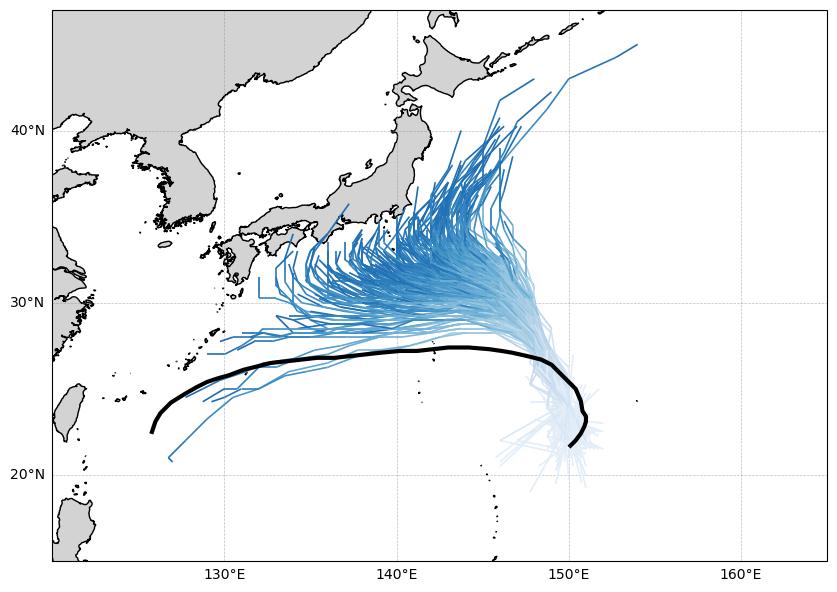

In [2]:
#==========================
# 태풍 지정 & 데이터 불러오기
#==========================

# storm_name, storm_year, key_time_list  = 'HINNAMNOR'  , 2022, ['2022/08/27/00UTC']
# storm_name, storm_year, key_time_list  = 'HINNAMNOR'  , 2022, ['2022/08/28/00UTC']
# storm_name, storm_year, key_time_list  = 'NORU'       , 2017, ['2017/07/30/00UTC']
# storm_name, storm_year, key_time_list  = 'DEBBY'      , 2012, ['2012/06/23/00UTC']                                                                               

# TC list for analysis
storm_configs = [
    # ('Ellie', 1991, ['1991/08/11/00UTC']),
    # ('Gladys', 1991, ['1991/08/15/00UTC']),
    # ('Gladys', 1994, ['1994/08/26/00UTC']),
    # ('JELAWAT', 2000, ['2000/08/02/00UTC']),
    # ('Fung-Wong', 2002, ['2002/07/19/00UTC']),
    # ('Fengshen', 2002, ['2002/07/22/00UTC']),
    # ('Sinlaku', 2002, ['2002/08/30/00UTC']),
    # ('Haitang', 2005, ['2005/07/11/00UTC']),
    # ('Damrey', 2012, ['2012/07/27/00UTC']),
    # ('Noru', 2017, ['2017/07/24/00UTC']),
    # ('Hinnamnor', 2022, ['2022/08/28/00UTC']),
    ('Hinnamnor', 2022, ['2022/08/27/00UTC'])
]

for storm_name, storm_year, key_time_list in storm_configs:

    #=================
    # IBTrACS TC Best track data 가져오기
    #=================
    ds = xr.open_dataset(rf'/home1/jek/Pangu-Weather/input_data/IBTrACS.WP.v04r01.nc')
    tc_ds = ds.where((ds['season'] == storm_year), drop=True)
    tc_ds['name_str'] = tc_ds['name'].str.decode('utf-8').str.strip()

    tc_ds = tc_ds.where(tc_ds['name_str'].str.upper() == storm_name.upper(), drop=True)
    storm_lat, storm_lon, storm_mslp, storm_time, storm_speed, storm_type = tc_ds['usa_lat'][0].values.astype(np.float32), tc_ds['usa_lon'][0].values.astype(np.float32), tc_ds['usa_pres'][0].values.astype(np.float32), tc_ds['iso_time'][0].values.astype('datetime64').astype(datetime), tc_ds['usa_wind'][0].values.astype(np.float32), tc_ds['nature'][0].values.astype('str')
    if any(lon < 0 for lon in storm_lon):
        storm_lon = [lon + 360 if lon < 0 else lon for lon in storm_lon]
    storm_lon = np.array(storm_lon)

    idx_mask = ~np.isnan(storm_lon)
    storm_lat, storm_lon, storm_mslp, storm_time, storm_speed, storm_type = storm_lat[idx_mask], storm_lon[idx_mask], storm_mslp[idx_mask], storm_time[idx_mask], storm_speed[idx_mask], storm_type[idx_mask]

    # 태풍 정보를 저장할 dictionary
    ssv_dict = {}
    #! 위경도 지정 (이전 실험과 다르게 90-180,0-60)
    if storm_name.upper() == 'DEBBY':
        lat_indices, lat_start, lat_end, lon_indices, lon_start, lon_end, extent, latlon_ratio = latlon_extent(250,310,5,45)  
    elif storm_name.upper() == 'HINNAMNOR' and key_time_list == ['2022/08/27/00UTC']:
        lat_indices, lat_start, lat_end, lon_indices, lon_start, lon_end, extent, latlon_ratio = latlon_extent(100,160,5,45) 
    else: 
        lat_indices, lat_start, lat_end, lon_indices, lon_start, lon_end, extent, latlon_ratio = latlon_extent(90,180,0,60)  
    lon_grid, lat_grid = np.meshgrid(lon_indices[lon_start:lon_end + 1], lat_indices[lat_start:lat_end + 1])


    #=========================
    # 새롭게 TC 위치 찾기
    #=========================
    if new_ssv == 'y':
        for first_str in key_time_list:
            first_time = datetime.strptime(first_str, "%Y/%m/%d/%HUTC")
            output_data_dir_base = rf'{pangu_dir}/output_data/{first_str}/{perturbation_scale}ENS{surface_str}{upper_str}{lat_perturb_suffix}{six_hour_suffix}'
            
            # 병렬 실행 (n_jobs=-1 은 사용 가능한 모든 코어 사용)
            results = Parallel(n_jobs=20, verbose=10)(
                delayed(process_single_ensemble)(
                    ens, first_time, predict_interval_list, start_track_time, output_data_dir_base,
                    surface_dict, upper_dict, lat_start, lat_end, lon_start, lon_end,
                    lat_grid, lon_grid, lat_indices, lon_indices, storm_lon, storm_lat,
                    storm_mslp, storm_time, retro_opt,
                    init_size=init_size, mask_size=mask_size, local_min_size=local_min_size, mslp_z_dis=mslp_z_dis, mslp_z_dis_td=mslp_z_dis_td, wind_thres=wind_thres, vort_thres=vort_thres, wind_vort_field=wind_vort_field, patience=patience
                ) for ens in ens_list
            )
            
            # 결과 합치기
            min_position = {ens: pos for ens, pos in results}
            ssv_dict[first_time] = min_position

        with open(rf'{pangu_dir}/output_data/{first_str}/{perturbation_scale}ENS{surface_str}{upper_str}{lat_perturb_suffix}{six_hour_suffix}/ssv_dict{retro_opt}_{min(ens_list)}_{max(ens_list)}.pkl', 'wb') as f:
            pickle.dump(ssv_dict, f)

    else:
        for first_str in key_time_list:
            first_time = datetime.strptime(first_str, "%Y/%m/%d/%HUTC")
            key_str = first_time.strftime("%m.%d.%HUTC")
            ssv_key = first_time
            surface_factors.sort()
            upper_factors.sort()
            surface_str = "".join([f"_{factor}" for factor in surface_factors])  # 각 요소 앞에 _ 추가
            upper_str = "".join([f"_{factor}" for factor in upper_factors])  # 각 요소 앞에 _ 추가
            
            datetime_list = np.array([first_time + timedelta(hours=int(hours)) for hours in predict_interval_list])

            with open(rf'{pangu_dir}/output_data/{first_str}/{perturbation_scale}ENS{surface_str}{upper_str}{lat_perturb_suffix}{six_hour_suffix}/ssv_dict{retro_opt}_{min(ens_list)}_{max(ens_list)}.pkl', 'rb') as f:
                ssv_dict = pickle.load(f)


    def normalize_lon(lon):
        """경도를 항상 -180~180 사이로 변환"""
        lon = np.array(lon)
        lon = ((lon + 180) % 360) - 180
        return lon



    #====================================================
    # Best Track 및 Pangu-Weather Ensemble 예측 트랙 그리기
    #====================================================
    
    print(f"Plot: {storm_name} ({storm_year})")
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    plot_extent = [120, 165, 15, 47]
    ax.set_extent(plot_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.coastlines("10m")


    wind_norm = mcolors.Normalize(vmin=20, vmax=140)
    original_cmap = plt.get_cmap('jet')
    new_jet = mcolors.LinearSegmentedColormap.from_list(
        'truncated_jet', 
        original_cmap(np.linspace(0, 1, 100)) # 0.2~0.8 구간을 100단계로 추출
    )
    ax.plot(storm_lon[:41], storm_lat[:41], color='black', linestyle='-', marker='', transform=ax.projection, zorder=10, linewidth=3)

    full_blues = plt.get_cmap('Blues')
    new_colors_blue = full_blues(np.linspace(0.1, 0.8, 256))
    blue_cmap = mcolors.LinearSegmentedColormap.from_list('Blues_truncated', new_colors_blue)
    num = 0
    min_position = ssv_dict[first_time]
    for ens in ens_list:  
        lons = [pos['lon'] for _,pos in min_position[ens].items()]
        lats = [pos['lat'] for _,pos in min_position[ens].items()]
        plot_ens_tracks(lons, lats, ax, cmap = blue_cmap, zorder = 8)
        # max_wind = [pos['max_wind'] for _,pos in min_position[ens].items()]
        # pred_times = [pos for pos,_ in min_position[ens].items()]
        num += 1 if len(lons)>0 else 0
        # lc = colorline(ax, lons, lats, z=max_wind, cmap=plt.get_cmap('jet'), norm=mcolors.Normalize(vmin=20/1.94384, vmax=140/1.94384), linewidth=2, alpha=1, zorder = 30)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.MultipleLocator(10)
    gl.ylocator = mticker.MultipleLocator(10)

    # cbar = plt.colorbar(sax, ax = ax, fraction=0.03, pad = 0.03)
    # cbar.set_label('Maximum Wind Speed (knots)', fontsize=12)


    ens_spread_dict = {}
    ens_error_dict = {}
    ens_num_dict = {}

    mid_pos = []
    for t in range(0, 121, 6):
        snap_time = first_time + timedelta(hours = t)
        tar_pos = []
        for ens, single_data in min_position.items():
            snap_data = min_position[ens].get(first_time+timedelta(hours=t), None)

            if snap_data:
                tar_pos.append([snap_data['lon'], snap_data['lat']])
                if t == 18:
                    mid_pos.append([snap_data['lon'], snap_data['lat']])

        if len(tar_pos) <= 1:
            continue
        else:
            tar_pos = np.array(tar_pos)

        snap_lon, snap_lat = storm_lon[storm_time == snap_time], storm_lat[storm_time == snap_time]
        avg_lon, avg_lat = weighted_avg_latlon(tar_pos[:,0], tar_pos[:,1])

        # ax.scatter(avg_lon, avg_lat, color = 'red', zorder = 11, s = 40)
        # ax.text(avg_lon, avg_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )
        # ax.scatter(snap_lon, snap_lat, color = 'black', zorder = 12, s=40)
        
        # ax.text(snap_lon, snap_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )

        corr_pos_tar = np.copy(tar_pos)
        corr_pos_tar[:, 0] = (tar_pos[:, 0]-np.mean(tar_pos[:, 0])) * np.cos(np.radians(tar_pos[:, 1]))  # 경도에 cos(위도)를 곱해 거리 왜곡 보정
        pca_tar = PCA(n_components=1)
        pca_tar.fit(corr_pos_tar)
        pca_tar.mean_[0] = pca_tar.mean_[0] / np.cos(np.radians(pca_tar.mean_[1])) + np.mean(tar_pos[:, 0])
        projection = pca_tar.transform(corr_pos_tar)[:, 0]  # 주축에 투영된 데이터 (1차원)
        distances_tar = (projection - np.mean(projection)) * 111
        ens_spread_dict[t] = np.std(distances_tar, ddof = 1).round(1)
        ens_error_dict[t] = haversine_distance(snap_lon, snap_lat, avg_lon, avg_lat).round(1)
        ens_num_dict[t] = len(distances_tar)

    print(ens_spread_dict)
    print(ens_error_dict)
    print(ens_num_dict)

    # ax.scatter(np.array(mid_pos)[:,0], np.array(mid_pos)[:,1], color = 'green', zorder = 12, s=15)

    print(f"{num}/{len(ens_list)} ensembles predicted the track.")
    plt.show()

Plot: Hinnamnor (2022)
{0: 167.8, 6: 76.4, 12: 21.3, 18: 53.2, 24: 42.4, 30: 47.9, 36: 59.3, 42: 75.9, 48: 101.2, 54: 122.9, 60: 150.0, 66: 187.3, 72: 231.7, 78: 290.6, 84: 357.4, 90: 439.4, 96: 533.7, 102: 634.0, 108: 824.5, 114: 948.6, 120: 1004.7}
{0: array([95.2]), 6: array([97.4]), 12: array([159.3]), 18: array([247.6]), 24: array([267.8]), 30: array([263.5]), 36: array([285.8]), 42: array([329.9]), 48: array([382.2]), 54: array([436.4]), 60: array([507.6]), 66: array([597.]), 72: array([705.4]), 78: array([817.6]), 84: array([967.6]), 90: array([1036.7]), 96: array([1186.7]), 102: array([1240.2]), 108: array([1307.]), 114: array([1417.1]), 120: array([1369.2])}
{0: 169, 6: 218, 12: 449, 18: 449, 24: 449, 30: 449, 36: 449, 42: 449, 48: 448, 54: 446, 60: 440, 66: 421, 72: 406, 78: 312, 84: 284, 90: 146, 96: 87, 102: 54, 108: 29, 114: 20, 120: 13}
500/500 ensembles predicted the track.


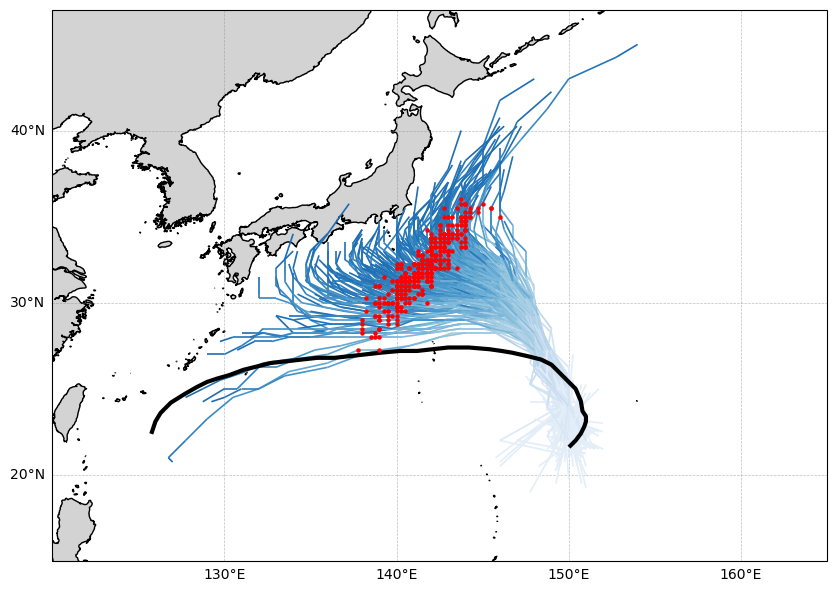

(0.0, 550.0)

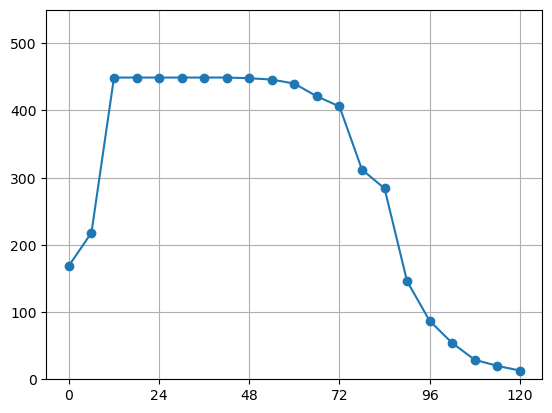

In [5]:
plot_time = 72

print(f"Plot: {storm_name} ({storm_year})")
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
plot_extent = [120, 165, 15, 47]
ax.set_extent(plot_extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.coastlines("10m")


wind_norm = mcolors.Normalize(vmin=20, vmax=140)
original_cmap = plt.get_cmap('jet')
new_jet = mcolors.LinearSegmentedColormap.from_list(
    'truncated_jet', 
    original_cmap(np.linspace(0, 1, 100)) # 0.2~0.8 구간을 100단계로 추출
)
ax.plot(storm_lon[:41], storm_lat[:41], color='black', linestyle='-', marker='', transform=ax.projection, zorder=10, linewidth=3)

full_blues = plt.get_cmap('Blues')
new_colors_blue = full_blues(np.linspace(0.1, 0.8, 256))
blue_cmap = mcolors.LinearSegmentedColormap.from_list('Blues_truncated', new_colors_blue)
num = 0
min_position = ssv_dict[first_time]
for ens in ens_list:  
    lons = [pos['lon'] for _,pos in min_position[ens].items()]
    lats = [pos['lat'] for _,pos in min_position[ens].items()]
    plot_ens_tracks(lons, lats, ax, cmap = blue_cmap, zorder = 8)
    # max_wind = [pos['max_wind'] for _,pos in min_position[ens].items()]
    # pred_times = [pos for pos,_ in min_position[ens].items()]
    num += 1 if len(lons)>0 else 0
    # lc = colorline(ax, lons, lats, z=max_wind, cmap=plt.get_cmap('jet'), norm=mcolors.Normalize(vmin=20/1.94384, vmax=140/1.94384), linewidth=2, alpha=1, zorder = 30)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(10)
gl.ylocator = mticker.MultipleLocator(10)

# cbar = plt.colorbar(sax, ax = ax, fraction=0.03, pad = 0.03)
# cbar.set_label('Maximum Wind Speed (knots)', fontsize=12)


ens_spread_dict = {}
ens_error_dict = {}
ens_num_dict = {}

mid_pos = []
for t in range(0, 121, 6):
    snap_time = first_time + timedelta(hours = t)
    tar_pos = []
    for ens, single_data in min_position.items():
        snap_data = min_position[ens].get(first_time+timedelta(hours=t), None)
        first_data = min_position[ens].get(first_time+timedelta(hours=12), None)

        if snap_data and first_data:
            tar_pos.append([snap_data['lon'], snap_data['lat']])
            if t == plot_time:
                mid_pos.append([snap_data['lon'], snap_data['lat']])

    if len(tar_pos) <= 1:
        continue
    else:
        tar_pos = np.array(tar_pos)

    snap_lon, snap_lat = storm_lon[storm_time == snap_time], storm_lat[storm_time == snap_time]
    avg_lon, avg_lat = weighted_avg_latlon(tar_pos[:,0], tar_pos[:,1])

    # ax.scatter(avg_lon, avg_lat, color = 'red', zorder = 11, s = 40)
    # ax.text(avg_lon, avg_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )
    # ax.scatter(snap_lon, snap_lat, color = 'black', zorder = 12, s=40)
    
    # ax.text(snap_lon, snap_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )

    corr_pos_tar = np.copy(tar_pos)
    corr_pos_tar[:, 0] = (tar_pos[:, 0]-np.mean(tar_pos[:, 0])) * np.cos(np.radians(tar_pos[:, 1]))  # 경도에 cos(위도)를 곱해 거리 왜곡 보정
    pca_tar = PCA(n_components=1)
    pca_tar.fit(corr_pos_tar)
    pca_tar.mean_[0] = pca_tar.mean_[0] / np.cos(np.radians(pca_tar.mean_[1])) + np.mean(tar_pos[:, 0])
    projection = pca_tar.transform(corr_pos_tar)[:, 0]  # 주축에 투영된 데이터 (1차원)
    distances_tar = (projection - np.mean(projection)) * 111
    ens_spread_dict[t] = np.std(distances_tar, ddof = 1).round(1)
    ens_error_dict[t] = haversine_distance(snap_lon, snap_lat, avg_lon, avg_lat).round(1)
    ens_num_dict[t] = len(distances_tar)

print(ens_spread_dict)
print(ens_error_dict)
print(ens_num_dict)

ax.scatter(np.array(mid_pos)[:,0], np.array(mid_pos)[:,1], color = 'red', zorder = 12, s=5)

print(f"{num}/{len(ens_list)} ensembles predicted the track.")
plt.show()

plt.plot(ens_num_dict.keys(), list(ens_num_dict.values()), marker='o')
plt.grid()
plt.xticks(range(0, 121, 24))
plt.ylim(0,550)

## Draw TC data 🌀

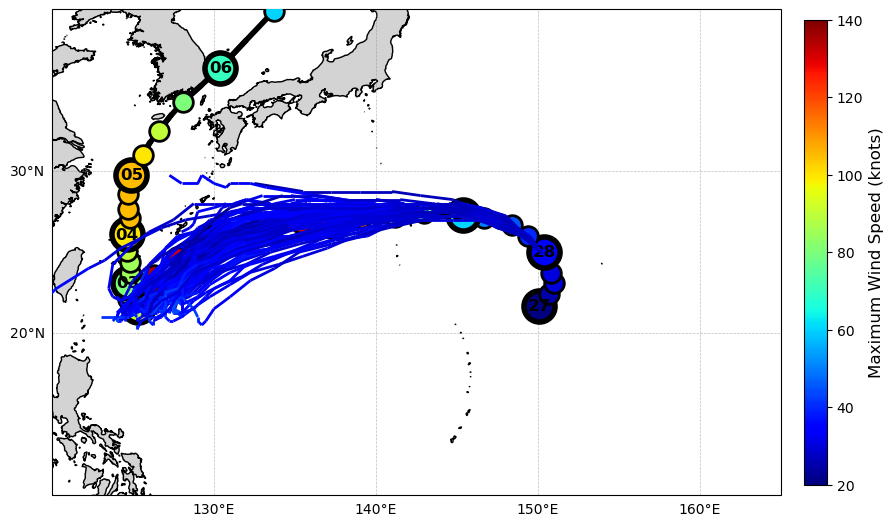

100


In [7]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
plot_extent = [120, 165, 10, 40]
ax.set_extent(plot_extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.coastlines("10m")


wind_norm = mcolors.Normalize(vmin=20, vmax=140)
original_cmap = plt.get_cmap('jet')
new_jet = mcolors.LinearSegmentedColormap.from_list(
    'truncated_jet', 
    original_cmap(np.linspace(0, 1, 100)) # 0.2~0.8 구간을 100단계로 추출
)
for i in range(len(storm_lon[~np.isnan(storm_lon)]))[::2]:
        # Plot the storm track with the corresponding color
    ax.plot(storm_lon[i: i+4], storm_lat[i: i+4], color='black', linestyle='-', marker='', transform=ax.projection, zorder=10, linewidth=4)
    sax = ax.scatter(storm_lon[i], storm_lat[i], c=storm_speed[i], cmap = new_jet, norm = wind_norm, transform=ax.projection, zorder=10, s=200, edgecolors='black', linewidth=2)


    new_time = storm_time[i].strftime("%Y/%m/%d/%HUTC")
    if new_time.endswith('00UTC'):
        ax.scatter(storm_lon[i], storm_lat[i], c=storm_speed[i], cmap = new_jet, norm = wind_norm, transform=ax.projection, zorder=10, s=500, edgecolors='black', linewidth=4)
        dx, dy = 0, -0  # 시간 나타낼 위치 조정
        new_lon, new_lat = storm_lon[i] + dx, storm_lat[i] + dy
        
        # annotate를 사용하여 텍스트와 함께 선(화살표)을 그림
        if new_lon >= plot_extent[0] and new_lon <= plot_extent[1] and new_lat >= plot_extent[2] and new_lat <= plot_extent[3]:
            ax.text(new_lon, new_lat, new_time[8:-6]
                    , horizontalalignment='center', verticalalignment='center', fontsize=12, zorder = 20, fontweight = 'bold')

num = 0
for ens in ens_list:  
    lons = [pos['lon'] for _,pos in min_position[ens].items()]
    lats = [pos['lat'] for _,pos in min_position[ens].items()]
    max_wind = [pos['max_wind'] for _,pos in min_position[ens].items()]
    pred_times = [pos for pos,_ in min_position[ens].items()]

    num +=1 if lons else 0
    lc = colorline(ax, lons, lats, z=max_wind, cmap=plt.get_cmap('jet'), norm=mcolors.Normalize(vmin=20/1.94384, vmax=140/1.94384), linewidth=2, alpha=1, zorder = 30)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(10)
gl.ylocator = mticker.MultipleLocator(10)

cbar = plt.colorbar(sax, ax = ax, fraction=0.03, pad = 0.03)
cbar.set_label('Maximum Wind Speed (knots)', fontsize=12)
plt.show()
print(num)

## Remove TC wind from steerig flow

In [11]:
import numpy as np
import os
import xarray as xr
from datetime import timedelta, datetime
from tqdm import tqdm
from dask import delayed, compute
from collections import defaultdict
from tool.ty_pkg import WindFieldSolver, get_factorized_solver

key_time = datetime(2022,8,27,0)             #처음 시점 지정
start_time = datetime(2022,8,27,12)           #분석 시작 시점
target_time = datetime(2022,8,30,0)           #위치 projection을 구하고자 하는 시간

# ─── 1. 실험 조건 및 검증 파라미터 설정 ───────────────────────────────────────
# 테스트할 반경 리스트 (km)
analysis_hour_list = [12]
radii_list = [100, 150, 200, 250, 300, 350, 400, 500] 

# 테스트할 고도 범위 및 가중치 (제시해주신 값 적용)
steer_pres = [850, 700, 600, 500, 400, 300, 250]

pres_ranges = {
    850: [850],
    700: [850, 700],
    600: [850, 700, 600],
    500: [850, 700, 600, 500],
    400: [850, 700, 600, 500, 400],
    300: [850, 700, 600, 500, 400, 300],
    250: [850, 700, 600, 500, 400, 300, 250],
}

weight_ranges = {
    850: [112.5],
    700: [112.5, 125],
    600: [112.5, 125, 100],
    500: [112.5, 125, 100, 100],
    400: [112.5, 125, 100, 100, 100],
    300: [112.5, 125, 100, 100, 100, 75],
    250: [112.5, 125, 100, 100, 100, 75, 50]
}

# ─── 2. Solver 사전 계산 (Pre-factorization) ──────────────────────────────────
print(f"Building factorized Poisson solver for grid shape {lat_grid.shape}...")
_poisson_solver = get_factorized_solver(lat_grid, dx=111e3/4, dy=111e3/4)
_poisson_solver_grid_shape = lat_grid.shape
print("Solver ready.")

# ─── 3. Dask Task 정의 (영역 평균 포함) ───────────────────────────────────────
@delayed
def solve_steer_task(ens, lev_hpa, predict_interval, center_lat, center_lon,
                     output_data_dir, surface_dict, upper_dict, 
                     lat_start, lat_end, lon_start, lon_end, radius, 
                     lat_grid, lon_grid, sparse_solver):
    """특정 멤버, 고도, 반경에 대해 TC 제거 후 영역 평균 u, v를 반환"""
    
    # Met 객체 생성 (사용자 라이브러리 가정)
    met = Met(output_data_dir, predict_interval, surface_dict, upper_dict,
              lat_start, lat_end, lon_start, lon_end, lat_grid, lon_grid)

    u = met.met_data('u', level=lev_hpa).copy()
    v = met.met_data('v', level=lev_hpa).copy()
    vort = met.vorticity(level=lev_hpa)
    div  = met.divergence(level=lev_hpa)

    # WindFieldSolver 실행 (radius 인자 포함)
    solver = WindFieldSolver(lat_grid, lon_grid, center_lat, center_lon,
                             vort, div, max_iter=50000, tol=1e-2,
                             sparse_solver=sparse_solver, radius=radius)
    u_ty, v_ty = solver.solve()
    
    # Steering Wind 추출
    u_st = u - u_ty
    v_st = v - v_ty

    # --- Haversine Masking (해당 반경 내 평균 계산) ---
    deg2rad = np.pi / 180.0
    R_km = 6371.0
    dlat = (lat_grid - center_lat) * deg2rad
    dlon = (lon_grid - center_lon) * np.cos(center_lat * deg2rad) * deg2rad
    dist_km = R_km * np.sqrt(dlat**2 + dlon**2) # 간이 거리 계산 혹은 하버사인 사용 가능

    mask = dist_km <= radius
    u_mean = float(np.nanmean(u_st[mask]))
    v_mean = float(np.nanmean(v_st[mask]))

    return ens, lev_hpa, radius, u_mean, v_mean

# ─── 4. 메인 루프 (연산 수행) ──────────────────────────────────────────────────
results_dict = {} # 최종 결과를 저장할 딕셔너리

# 분석 시간 루프 (12시간 등)
ens_num_list = [ens for ens in ens_list if (start_time in ssv_dict[key_time][ens]) and (target_time in ssv_dict[key_time][ens])]
for predict_interval in tqdm(analysis_hour_list, desc="Predict Interval"):
    datetime1 = key_time + timedelta(hours=int(predict_interval))
    tasks = []
    
    # 앙상블 멤버 루프
    for ens in ens_num_list:
        center_lon = ssv_dict[key_time][ens][datetime1]['lon']
        center_lat = ssv_dict[key_time][ens][datetime1]['lat']
        output_data_dir = rf'{pangu_dir}/output_data/{first_str}/{perturbation_scale}ENS{surface_str}{upper_str}{lat_perturb_suffix}{six_hour_suffix}/{ens}'

        # 모든 고도와 모든 반경 조합에 대해 Task 생성
        for lev in steer_pres:
            for r in radii_list:
                tasks.append(solve_steer_task(
                    ens, lev, predict_interval, center_lat, center_lon,
                    output_data_dir, surface_dict, upper_dict,
                    lat_start, lat_end, lon_start, lon_end,
                    r, lat_grid, lon_grid, _poisson_solver
                ))

    print(f"  T+{predict_interval}h: {len(tasks)} tasks 컴퓨팅 시작 (Sparse Solver)...")
    raw_results = compute(*tasks, scheduler="synchronous")
    print(f"  Done.")

    # ─── 5. 결과 수집 및 가중 평균 (Weight 적용) ──────────────────────────────
    # interval_results[range_name][radius] = {'u': [], 'v': []}
    interval_results = defaultdict(lambda: defaultdict(lambda: {'u': [], 'v': []}))
    
    for ens in ens_num_list:
        for r in radii_list:
            for range_name, levels in pres_ranges.items():
                # 해당 앙상블, 반경, 지정된 고도 리스트에 해당하는 결과값 추출
                u_vals = [res[3] for res in raw_results if res[0]==ens and res[2]==r and res[1] in levels]
                v_vals = [res[4] for res in raw_results if res[0]==ens and res[2]==r and res[1] in levels]

                if u_vals:
                    # 사용자 지정 weight_ranges를 사용하여 가중 평균 계산
                    w = weight_ranges[range_name]
                    layer_u_mean = np.average(u_vals, weights=w)
                    layer_v_mean = np.average(v_vals, weights=w)

                    interval_results[range_name][r]['u'].append(layer_u_mean)
                    interval_results[range_name][r]['v'].append(layer_v_mean)
    
    results_dict[predict_interval] = interval_results

print("\n[완료] 모든 조합(반경/고도/가중치)에 대한 Steering Wind 계산이 끝났습니다.")

# --- 이후 RMSE 계산 및 시각화 코드는 동일하게 사용 가능합니다 ---

Building factorized Poisson solver for grid shape (161, 241)...
Solver ready.


Predict Interval:   0%|          | 0/1 [00:00<?, ?it/s]

  T+12h: 22736 tasks 컴퓨팅 시작 (Sparse Solver)...
  Done.


Predict Interval: 100%|██████████| 1/1 [08:56<00:00, 536.73s/it]


[완료] 모든 조합(반경/고도/가중치)에 대한 Steering Wind 계산이 끝났습니다.


In [12]:
del_x_list = []
del_y_list = []

for mem in ens_num_list:
    first_lon = ssv_dict[key_time][mem][key_time + timedelta(hours=12)]['lon']
    first_lat = ssv_dict[key_time][mem][key_time + timedelta(hours=12)]['lat']
    second_lon = ssv_dict[key_time][mem][key_time + timedelta(hours=18)]['lon']
    second_lat = ssv_dict[key_time][mem][key_time + timedelta(hours=18)]['lat']
    del_lon = second_lon - first_lon
    del_lat = second_lat - first_lat    
    del_x = del_lon * np.cos(np.radians((first_lat + second_lat) / 2)) * 111
    del_y = del_lat * 111
    del_x_list.append(del_x)
    del_y_list.append(del_y)

del_x_array = np.array(del_x_list)
del_y_array = np.array(del_y_list)

Range: 850, Radius: 100km → RMSE: 70.20 km
Range: 850, Radius: 150km → RMSE: 56.59 km
Range: 850, Radius: 200km → RMSE: 52.04 km
Range: 850, Radius: 250km → RMSE: 53.41 km
Range: 850, Radius: 300km → RMSE: 57.59 km
Range: 850, Radius: 350km → RMSE: 63.14 km
Range: 850, Radius: 400km → RMSE: 68.33 km
Range: 850, Radius: 500km → RMSE: 75.65 km
Range: 700, Radius: 100km → RMSE: 81.22 km
Range: 700, Radius: 150km → RMSE: 62.92 km
Range: 700, Radius: 200km → RMSE: 53.18 km
Range: 700, Radius: 250km → RMSE: 51.02 km
Range: 700, Radius: 300km → RMSE: 52.14 km
Range: 700, Radius: 350km → RMSE: 54.85 km
Range: 700, Radius: 400km → RMSE: 58.34 km
Range: 700, Radius: 500km → RMSE: 65.60 km
Range: 600, Radius: 100km → RMSE: 95.91 km
Range: 600, Radius: 150km → RMSE: 73.65 km
Range: 600, Radius: 200km → RMSE: 58.94 km
Range: 600, Radius: 250km → RMSE: 54.10 km
Range: 600, Radius: 300km → RMSE: 54.21 km
Range: 600, Radius: 350km → RMSE: 55.63 km
Range: 600, Radius: 400km → RMSE: 57.82 km
Range: 600,

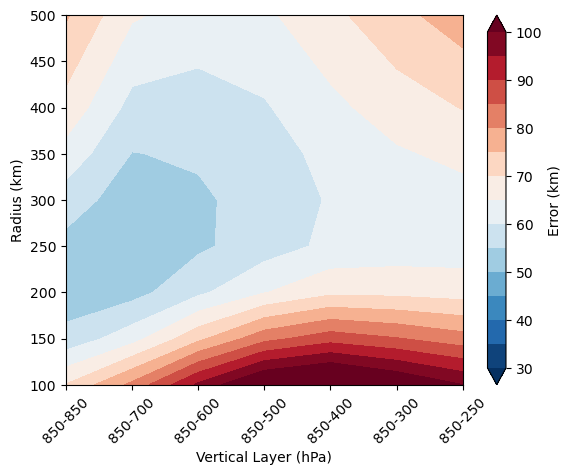

In [13]:
rmse = np.zeros((len(radii_list), len(pres_ranges)))
for i, range_name in enumerate(pres_ranges.keys()):
    for j, r in enumerate(radii_list):
        tc_rm_del_x = np.array(results_dict[12][range_name][r]['u']) * 21.6
        tc_rm_del_y = np.array(results_dict[12][range_name][r]['v']) * 21.6

        rmse[j, i] = np.mean(np.sqrt((del_x_array - tc_rm_del_x)**2 + (del_y_array - tc_rm_del_y)**2))
        print(f"Range: {range_name}, Radius: {r}km → RMSE: {rmse[j, i]:.2f} km")

x_labels = [f"{hpa[0]}-{hpa[-1]}" for hpa in pres_ranges.values()]
# prime_r = radii_list[np.argmin(rmse, axis=0)]  # 각 고도 범위별로 가장 낮은 RMSE를 주는 반경 인덱스
# x_labels[np.argmin(rmse, axis=1)]  # 각 고도 범위별로 가장 낮은 RMSE를 주는 고도 범위 레이블

min_j, min_i = np.unravel_index(np.argmin(rmse), rmse.shape)

best_radius = radii_list[min_j]
best_p_range = x_labels[min_i]
min_rmse_val = rmse[min_j, min_i]

print("-" * 30)
print(f"🏆 최적의 지향류 설정 (Minimum RMSE)")
print(f"📍 고도 범위 (P-layer): {best_p_range} hPa")
print(f"📍 계산 반경 (Radius) : {best_radius} km")
print(f"📉 최소 RMSE 값      : {min_rmse_val:.2f} km")
print("-" * 30)

plt.contourf(x_labels, radii_list, rmse, levels = np.arange(30, 101, 5), cmap='RdBu_r', extend = 'both')
plt.xlabel('Vertical Layer (hPa)')
plt.xticks(rotation=45)
plt.ylabel('Radius (km)')
plt.colorbar(label='Error (km)')
plt.show()


# Steering Wind 계산 후 저장하는 코드

In [15]:
from tqdm import tqdm

# Precompute factorized Poisson solver - done once, reused for all ensemble solves
from tool.ty_pkg import get_factorized_solver
print(f"Building and factorizing sparse Poisson matrix for grid shape {lat_grid.shape}...")
_poisson_solver = get_factorized_solver(lat_grid, dx=111e3/4, dy=111e3/4)
_poisson_solver_grid_shape = lat_grid.shape
print(f"Sparse solver ready. Grid shape: {_poisson_solver_grid_shape}")

if storm_name.upper() == 'HINNAMNOR':
    # key_time = datetime(2022,8,27,0)             #처음 시점 지정
    # start_time = datetime(2022,8,28,0)           #분석 시작 시점
    # target_time = datetime(2022,8,31,0)           #위치 projection을 구하고자 하는 시간
    key_time = datetime(2022,8,27,0)             #처음 시점 지정
    start_time = datetime(2022,8,27,12)           #분석 시작 시점
    target_time = datetime(2022,8,30,0)           #위치 projection을 구하고자 하는 시간
elif storm_name.upper() == 'NORU':
    key_time = datetime(2017,7,30,0)              #처음 시점 지정
    start_time = datetime(2017,7,30,0)            #분석 시작 시점
    target_time = datetime(2017,8,4,0)            #위치 projection을 구하고자 하는 시간
elif storm_name.upper() == 'DEBBY':
    key_time = datetime(2012,6,23,0)              #처음 시점 지정
    start_time = datetime(2012,6,24,0)            #분석 시작 시점
    target_time = datetime(2012,6,26,0)            #위치 projection을 구하고자 하는 시간

key_str = key_time.strftime("%m.%d %HUTC")
start_str = start_time.strftime("%m.%d %HUTC")
target_str = target_time.strftime("%m.%d %HUTC")

total_time_range = int((target_time - key_time).total_seconds() / 3600)
start_time_range = int((start_time  - key_time).total_seconds() / 3600)

# 변수 지정
loc_corr_sign = 'n'                         #가까운 위치에 대해서만 진행할 것인가
choosen_factor_list = ['steering_wind'] #구하고자 하는 변수
steer_pres = [850,700, 600, 250]        #steering wind 구할 때 사용하는 고도 
tc_radius = 250                             #TC 제거할 때 사용하는 반경 (km)``
axis_opt = 'opt'                            #axis 뭘로 잡을지
data_sign = 'n'                             #기존의 데이터를 사용할 것인지
six_h_opt = 'y'                             #6시간 간격으로 할 것인지

if six_h_opt == 'y':
    six_hour_suffix = '_6h'
else:
    six_hour_suffix = ''



# target_time 때도 살아있는 태풍만 추출
ens_num_list = []
for ens in range(ens_num):
    if (target_time in ssv_dict[key_time][ens]) and (start_time in ssv_dict[key_time][ens]):
        ens_num_list.append(ens)
print('Total num: ',len(ens_num_list))


ens_pos = [(ens, ssv_dict[key_time][ens][target_time]['lon'], ssv_dict[key_time][ens][target_time]['lat']) for ens in ens_num_list]
correlations = []
correlations_opt = []
correlations_df = []


def get_subdomain_indices(lat_grid, lon_grid, center_lat, center_lon, dlat=10, dlon=10):
    lat_vals = lat_grid[:, 0]
    lon_vals = lon_grid[0, :]

    lat_min = center_lat - dlat
    lat_max = center_lat + dlat
    lon_min = center_lon - dlon
    lon_max = center_lon + dlon

    i_start = np.searchsorted(lat_vals, lat_min, side='left')
    i_end   = np.searchsorted(lat_vals, lat_max, side='right')
    j_start = np.searchsorted(lon_vals, lon_min, side='left')
    j_end   = np.searchsorted(lon_vals, lon_max, side='right')
    return i_start, i_end, j_start, j_end


from dask import delayed, compute
import numpy as np
from datetime import timedelta


############################################
# Dask Task
############################################

@delayed
def solve_ty_remove_task(
        ens,
        steer_altitude,
        tc_radius,
        predict_interval,
        key_time,
        datetime1,
        output_data_dir,
        center_lat,
        center_lon,
        lat_grid,
        lon_grid,
        surface_dict,
        upper_dict,
        lat_start,
        lat_end,
        lon_start,
        lon_end,
        sparse_solver=None):

    met = Met(
        output_data_dir,
        predict_interval,
        surface_dict,
        upper_dict,
        lat_start,
        lat_end,
        lon_start,
        lon_end,
        lat_grid,
        lon_grid
    )

    vort = met.vorticity(level=steer_altitude)
    div  = met.divergence(level=steer_altitude)

    solver = WindFieldSolver(
        lat_grid,
        lon_grid,
        center_lat,
        center_lon,
        vort,
        div,
        max_iter=50000,
        tol=1e-2,
        sparse_solver=sparse_solver,
        radius=tc_radius
    )

    u_ty, v_ty = solver.solve()

    return (
        ens,
        steer_altitude,
        u_ty,
        v_ty,
    )


############################################
# MAIN LOOP
############################################

for predict_interval in tqdm(np.arange(12,13,6), desc="Predict Interval"):

    assert lat_grid.shape == _poisson_solver_grid_shape, \
        f"lat_grid changed ({lat_grid.shape} != {_poisson_solver_grid_shape}). Re-run the solver precomputation cell."

    datetime1 = key_time + timedelta(hours=int(predict_interval))

    tasks = []

    for ens in ens_num_list:

        center_lon = ssv_dict[key_time][ens][datetime1]['lon']
        center_lat = ssv_dict[key_time][ens][datetime1]['lat']

        output_data_dir = rf'{pangu_dir}/output_data/{first_str}/{perturbation_scale}ENS{surface_str}{upper_str}{lat_perturb_suffix}{six_hour_suffix}/{ens}'

        for steer_altitude in steer_pres:

            task = solve_ty_remove_task(
                ens,
                steer_altitude,
                tc_radius,
                predict_interval,
                key_time,
                datetime1,
                output_data_dir,
                center_lat,
                center_lon,
                lat_grid,
                lon_grid,
                surface_dict,
                upper_dict,
                lat_start,
                lat_end,
                lon_start,
                lon_end,
                sparse_solver=_poisson_solver
            )

            tasks.append(task)

    ############################################
    # PARALLEL EXECUTION
    # NOTE: scheduler="synchronous" is required because _poisson_solver wraps a
    # scipy SuperLU factorization object, which is not picklable (rules out
    # "processes") and whose thread-safety is undocumented (rules out "threads").
    # Tasks run sequentially but each Poisson solve is ~1ms (sparse direct),
    # so total runtime is still fast (~90s for 45k tasks).
    ############################################

    print(f"  Running {len(tasks)} parallel tasks (sparse solver)...")
    results = compute(*tasks, scheduler="synchronous")
    print(f"  Done.")

    ############################################
    # Collect results
    ############################################

    results_dict = {}

    for res in results:

        ens, level, u_tc, v_tc = res

        results_dict[(ens, level)] = (u_tc, v_tc)

    ############################################
    # Apply TC removal
    ############################################

    all_u = []
    all_v = []

    for ens in ens_num_list:

        output_data_dir = rf'{pangu_dir}/output_data/{first_str}/{perturbation_scale}ENS{surface_str}{upper_str}{lat_perturb_suffix}{six_hour_suffix}/{ens}'

        met = Met(
            output_data_dir,
            predict_interval,
            surface_dict,
            upper_dict,
            lat_start,
            lat_end,
            lon_start,
            lon_end,
            lat_grid,
            lon_grid
        )

        u_list = []
        v_list = []

        for steer_altitude in steer_pres:

            u = met.met_data('u', level=steer_altitude).copy()
            v = met.met_data('v', level=steer_altitude).copy()

            u_tc, v_tc = results_dict[(ens, steer_altitude)]

            u -= u_tc
            v -= v_tc

            u_list.append(u)
            v_list.append(v)

        all_u.append(u_list)
        all_v.append(v_list)

    # Base path for output data
    base_output_path = os.path.join(
        pangu_dir, 
        'output_data', 
        first_str, 
        f'{perturbation_scale}ENS{surface_str}{upper_str}{six_hour_suffix}', 
        f'{start_str}_{target_str}_e{ens_num}'
    )

    # Paths for saving the arrays
    ens_factor_uv_path = os.path.join(base_output_path, 'ens_factor_uv')
    u_mean_path = os.path.join(base_output_path, 'u_mean')
    v_mean_path = os.path.join(base_output_path, 'v_mean')

    # Ensure all required directories exist
    os.makedirs(ens_factor_uv_path, exist_ok=True)
    os.makedirs(u_mean_path, exist_ok=True)
    os.makedirs(v_mean_path, exist_ok=True)


    np.save(f'{ens_factor_uv_path}/{predict_interval}h.npy', np.array([all_u, all_v]))

    np.save(f'{u_mean_path}/{predict_interval}h.npy', np.mean(all_u, axis=0))

    np.save(f'{v_mean_path}/{predict_interval}h.npy', np.mean(all_v, axis=0))

Building and factorizing sparse Poisson matrix for grid shape (161, 241)...
Sparse solver ready. Grid shape: (161, 241)
Total num:  406


Predict Interval:   0%|          | 0/1 [00:00<?, ?it/s]

  Running 1624 parallel tasks (sparse solver)...
  Done.


Predict Interval: 100%|██████████| 1/1 [00:50<00:00, 50.34s/it]
